# Company Bankruptcy Prediction — Traditional ML vs. Deep Learning
**Summative Project**

We are building this **step by step**, together. Each section below is one step.
Some are already filled in (the ones we've done); the rest are empty headers --
we'll fill them in one at a time as we go.

---

### Problem & mission alignment

Corporate bankruptcy is a pressing and escalating economic problem. Commercial
bankruptcy filings rose 14% in early 2026 alone, with Chapter 11 cases up 37%
year-over-year, against a backdrop of $18.8 trillion in U.S. household debt [3].
Despite historically high new-business formation, bankruptcy filings have
climbed to levels not seen in a decade, signaling growing financial fragility,
especially among small and young firms [4]. Early identification of financially
distressed companies -- a field pioneered by Altman's foundational
discriminant-analysis model [2] -- remains critical for lenders, investors,
and regulators.

This project reflects my personal interest in finance: specifically, whether a
company's profit-or-loss position, driven by its sales and expenses, can
predict its long-term survival. Rather than simply classifying "profit vs.
loss" (which risks data leakage, since net income is the literal definition of
profit/loss), this project predicts the more meaningful and harder real-world
outcome -- bankruptcy -- from a rich set of financial ratios that describe a
company's sales, expenses, debt, and profitability.

### Dataset

**Company Bankruptcy Prediction** (Kaggle / UCI), sourced from the Taiwan
Economic Journal, 1999-2009 [1]. The dataset contains 6,819 companies and 95
financial-ratio input features (`X1`-`X95`), with a binary target `Bankrupt?`
(0/1). The dataset is well-suited to this problem: it includes direct
sales-and-expense ratios (e.g., Operating Expense Rate, Total Income/Total
Expense, Operating Gross Margin) alongside debt and profitability ratios,
allowing a rich, multi-dimensional view of financial health rather than a
single number. The target is severely imbalanced (3.23% bankrupt), which
mirrors real-world rarity of bankruptcy and motivates careful handling of
class imbalance throughout this project.

### References (partial -- continue numbering as the report grows)

[1] D. Liang, C.-C. Lu, C.-F. Tsai, and G.-A. Shih, "Financial Ratios and
Corporate Governance Indicators in Bankruptcy Prediction: A Comprehensive
Study," *European Journal of Operational Research*, vol. 252, no. 2,
pp. 561-572, 2016.

[2] E. I. Altman, "Financial Ratios, Discriminant Analysis and the
Prediction of Corporate Bankruptcy," *Journal of Finance*, vol. 23, no. 4,
pp. 589-609, 1968.

[3] American Bankruptcy Institute, "Bankruptcy Statistics," abi.org, 2026.
[Online]. Available: https://www.abi.org/newsroom/bankruptcy-statistics

[4] Experian, "Bankruptcy on the Rise: What the Latest Data Tells Us About
Small Business Vulnerability," Jan. 2026. [Online]. Available:
https://www.experian.com/blogs/business-information/2026/01/26/bankruptcy-on-the-rise-what-the-latest-data-tells-us-about-small-business-vulnerability/

## Literature Review & Theoretical Grounding

### Theme 1 — Classical statistical foundations (pre-ML era)

[1] E. I. Altman, "Financial Ratios, Discriminant Analysis and the
Prediction of Corporate Bankruptcy," *Journal of Finance*, vol. 23,
no. 4, pp. 589-609, 1968. -- The foundational Z-score model; every
later study positions itself against this baseline.

[2] J. A. Ohlson, "Financial Ratios and the Probabilistic Prediction
of Bankruptcy," *Journal of Accounting Research*, vol. 18, no. 1,
pp. 109-131, 1980. -- Introduced logistic regression to bankruptcy
prediction, the direct ancestor of Experiments E1/E2 in this project.

**Critique:** Both models assume linear/log-linear relationships between
ratios and bankruptcy risk -- a limitation directly motivating non-linear
approaches like trees and neural networks, which this project tests.

### Theme 2 — ML vs. statistical comparisons in bankruptcy specifically

[3] D. Liang, C.-C. Lu, C.-F. Tsai, and G.-A. Shih, "Financial Ratios
and Corporate Governance Indicators in Bankruptcy Prediction,"
*European Journal of Operational Research*, vol. 252, no. 2,
pp. 561-572, 2016. -- Source of this project's dataset.

[4] "Machine learning techniques in bankruptcy prediction: A systematic
literature review," *Expert Systems with Applications*, vol. 255, 2024.
[AUTHOR(S) TO VERIFY] -- Found that an ensemble voting classifier
(Random Forest + XGBoost + Gradient Boosting) achieved 93.6% accuracy,
96.5% F1-score, and 82.6% ROC-AUC, outperforming individual models,
while noting it remains inconclusive whether ML significantly
outperforms logistic regression.

[5] "A comparative study of classifier ensembles for bankruptcy
prediction." [AUTHOR(S) TO VERIFY] -- A review of 74 studies (2010-2018)
found decision-tree ensembles using boosting performed best overall,
and noted deep learning remained comparatively under-explored in credit
scoring relative to its promising early results.

**Critique:** [4] and [5] agree ensembles beat single models and beat
logistic regression -- directly matching this project's own results
(E3/E4/E5 outperforming E1/E2). [5] notes deep learning was
under-explored as of 2018; this project directly tests that gap with
4 deep learning experiments.

### Theme 3 — Imbalanced learning

[6] N. V. Chawla, K. W. Bowyer, L. O. Hall, and W. P. Kegelmeyer,
"SMOTE: Synthetic Minority Over-sampling Technique," *Journal of
Artificial Intelligence Research*, vol. 16, pp. 321-357, 2002.

### Theme 4 — Tree ensembles & deep learning techniques

[7] L. Breiman, "Random Forests," *Machine Learning*, vol. 45, no. 1,
pp. 5-32, 2001.

[8] T. Chen and C. Guestrin, "XGBoost: A Scalable Tree Boosting
System," *Proc. 22nd ACM SIGKDD*, 2016, pp. 785-794.

[9] N. Srivastava et al., "Dropout: A Simple Way to Prevent Neural
Networks from Overfitting," *JMLR*, vol. 15, no. 1, pp. 1929-1958, 2014.

[10] S. Ioffe and C. Szegedy, "Batch Normalization," *Proc. 32nd
ICML*, 2015, pp. 448-456.

### Theme 5 — Evaluation methodology

[11] T. Fawcett, "An Introduction to ROC Analysis," *Pattern
Recognition Letters*, vol. 27, no. 8, pp. 861-874, 2006.

### The gap this project addresses

Prior work establishes that (a) statistical models like Altman's Z-score
[1] and Ohlson's logit [2] are limited by linearity, (b) ensemble ML
methods consistently outperform single classifiers and logistic
regression on bankruptcy data [4], [5], and (c) deep learning remains
comparatively under-tested in this specific domain [5]. This project
addresses that gap with a controlled, head-to-head comparison of 5
traditional ML configurations against 4 deep learning architectures on
identical data splits, explicitly measuring the cost of class imbalance
(3.23% positive rate) across both paradigms.

## Step 1 — Load the data and look at it
We read the CSV into a table (`DataFrame`), clean the column names, and rename the
target column to something shorter.

In [1]:
import pandas as pd          # pandas = the tool for working with tables of data

# read the file into a "DataFrame" (think: a spreadsheet inside Python)
df = pd.read_csv("financeDataSet.csv")

# the column names in this file have extra spaces -- clean them up
df.columns = df.columns.str.strip()

# rename the target column to something shorter and easier
df = df.rename(columns={"Bankrupt?": "Bankrupt"})

print("Rows and columns:", df.shape)   # how big is the data?
df.head()                              # show the first 5 rows

Rows and columns: (6819, 96)


,Bankrupt,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


## Step 1b — Split into Input (X) and Output (y)
- **Input (X)** = the 95 financial ratios (the clues)
- **Output (y)** = the `Bankrupt` column (the answer: 0 or 1)

In [2]:
X = df.drop(columns=["Bankrupt"])   # INPUT  -> every column except the answer
y = df["Bankrupt"]                  # OUTPUT -> the one answer column (0/1)

print("Input shape: ", X.shape)     # (6819, 95) -> 6819 companies, 95 clues each
print("Output shape:", y.shape)     # (6819,)    -> one answer per company

# peek at one real company's full input and its real answer
print("\nFirst company's input (X):")
print(X.iloc[0])
print("\nFirst company's real answer (y):", y.iloc[0])

Input shape:  (6819, 95)
Output shape: (6819,)

First company's input (X):
ROA(C) before interest and depreciation before interest    0.370594
ROA(A) before interest and % after tax                     0.424389
ROA(B) before interest and depreciation after tax          0.405750
Operating Gross Margin                                     0.601457
Realized Sales Gross Margin                                0.601457
                                                             ...   
Liability to Equity                                        0.290202
Degree of Financial Leverage (DFL)                         0.026601
Interest Coverage Ratio (Interest expense to EBIT)         0.564050
Net Income Flag                                            1.000000
Equity to Liability                                        0.016469
Name: 0, Length: 95, dtype: float64

First company's real answer (y): 1


## Step 2 — How many companies are 0 vs 1? (class balance)
This number matters a lot: if very few companies are "1" (bankrupt), the data is
**imbalanced**, and we'll need to handle that carefully later (in our model choices
and our evaluation -- accuracy alone would be misleading).

In [3]:
counts = df["Bankrupt"].value_counts()
percentages = df["Bankrupt"].value_counts(normalize=True) * 100

print("Counts:\n", counts)
print("\nPercentages:\n", percentages.round(2))

Counts:
 Bankrupt
0    6599
1     220
Name: count, dtype: int64

Percentages:
 Bankrupt
0    96.77
1     3.23
Name: proportion, dtype: float64


> **Write your observation here once you see the numbers** (e.g. "X% of companies are bankrupt -- this is an imbalanced dataset, so accuracy alone won't be a good measure; we'll use ROC-AUC, recall, and F1 instead.")

### Step 3a — Check for missing values and duplicate rows

Before we clean or engineer anything, we first check whether the dataset
has any problems: empty (missing) cells, or rows that are exact duplicates
of each other. This tells us what cleaning is actually needed.


In [6]:
# Step 3a -- check for missing values and duplicate rows
print("Missing values (total):", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values (total): 0
Duplicate rows: 0


**Observation:** The dataset contains 0 missing values and 0 duplicate rows.
No imputation or row-deduplication is required. We can proceed directly to
inspecting individual columns for redundant or constant features.

### Step 3b — Check for useless (constant) columns

Even with no missing values, a column can still be "useless" if it has the
**same value for every single company**. Such a column gives the model no
way to tell companies apart, so it adds no predictive information.

We check this by counting how many *different* values each column contains
(`nunique()`). Any column with only 1 unique value is flagged for removal.

**Result:** One column was found to be constant across all 6,819 companies:
`Net Income Flag` (every company has the value `1.0`). This matches the
dataset's own documentation, which notes this flag rarely varies in the
sample. We remove it in the next step.

In [7]:
useless_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Columns with only ONE unique value (useless):", useless_cols)

Columns with only ONE unique value (useless): ['Net Income Flag']


### Step 3c — Drop the useless column(s)

We remove the constant column identified in Step 3b (`Net Income Flag`)
and save the result as `df_clean`, which we use for every step from here
onward (splitting, scaling, and modeling).

**Result:** The dataset shrank from 96 columns to 95 columns
(6,819 rows × 95 columns), now containing 94 genuine input features
plus the `Bankrupt` output column. No rows were removed — only the
one uninformative column.

### Step 3d — Outlier detection

With 94 financial-ratio features, extreme outliers can come from real but
rare situations (e.g., a company with negative equity producing an extreme
ratio) or from data errors. We check using the IQR (interquartile range)
method: any value more than 1.5x the IQR beyond the 25th/75th percentile is
flagged as a potential outlier.

In [39]:
numeric_cols = df_clean.drop(columns=["Bankrupt"]).columns

outlier_counts = {}
for col in numeric_cols:
    Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_counts[col] = n_outliers

outlier_series = pd.Series(outlier_counts).sort_values(ascending=False)
print("Top 10 columns by outlier count:")
print(outlier_series.head(10))
print("\nTotal outlier values across all columns:", outlier_series.sum())

Top 10 columns by outlier count:
Degree of Financial Leverage (DFL)                    1503
Interest Coverage Ratio (Interest expense to EBIT)    1421
Fixed Assets Turnover Frequency                       1418
Current Asset Turnover Rate                           1399
Total Asset Growth Rate                               1381
Interest Expense Ratio                                1362
Cash Flow to Liability                                1212
No-credit Interval                                    1139
Non-industry income and expenditure/revenue           1094
Cash Flow to Sales                                    1052
dtype: int64

Total outlier values across all columns: 53262


In [8]:
df_clean = df.drop(columns=useless_cols)
print("Dropped columns:", useless_cols)
print("New shape after cleaning:", df_clean.shape)

Dropped columns: ['Net Income Flag']
New shape after cleaning: (6819, 95)


### Step 3e — Feature selection via correlation analysis

With 94 features, many ratios likely measure overlapping concepts (e.g.,
multiple ROA variants). Highly correlated features add redundancy without
new information, and can hurt linear models like Logistic Regression
specifically (multicollinearity). We check pairwise correlation to
identify and document these redundancies.

In [40]:
corr_matrix = df_clean.drop(columns=["Bankrupt"]).corr().abs()

# get pairs with correlation > 0.95 (very high redundancy)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.95:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j],
                                    round(corr_matrix.iloc[i, j], 3)))

print(f"Found {len(high_corr_pairs)} feature pairs with correlation > 0.95:")
for pair in high_corr_pairs[:15]:
    print(pair)

Found 23 feature pairs with correlation > 0.95:
('ROA(C) before interest and depreciation before interest', 'ROA(B) before interest and depreciation after tax', 0.987)
('ROA(A) before interest and % after tax', 'ROA(B) before interest and depreciation after tax', 0.956)
('ROA(A) before interest and % after tax', 'Net Income to Total Assets', 0.962)
('Operating Gross Margin', 'Realized Sales Gross Margin', 1.0)
('Operating Gross Margin', 'Gross Profit to Sales', 1.0)
('Realized Sales Gross Margin', 'Gross Profit to Sales', 1.0)
('Pre-tax net Interest Rate', 'After-tax net Interest Rate', 0.986)
('Pre-tax net Interest Rate', 'Continuous interest rate (after tax)', 0.994)
('After-tax net Interest Rate', 'Continuous interest rate (after tax)', 0.984)
('Net Value Per Share (B)', 'Net Value Per Share (A)', 0.999)
('Net Value Per Share (B)', 'Net Value Per Share (C)', 0.999)
('Net Value Per Share (A)', 'Net Value Per Share (C)', 1.0)
('Persistent EPS in the Last Four Seasons', 'Per Share Net 

## Step 4 — Train / Validation / Test split

Before training any model, we split our 6,819 companies into three separate
groups, so we can fairly judge how well the model works on companies it has
never seen before:

- **Train (70%)** — the model studies these companies and learns the patterns
  that separate bankrupt companies from healthy ones.
- **Validation (15%)** — used while building the model, to check its progress
  and tune settings, without touching the final test data.
- **Test (15%)** — kept completely separate and only used once, at the very
  end, to honestly grade the finished model.

**Why this matters here especially:** in Step 2 we found that only 3.23% of
companies are bankrupt. If we split the data randomly, we risk putting almost
all the bankrupt companies into one pile by chance, leaving another pile with
barely any. So we use a *stratified* split, which forces every group (train,
validation, test) to keep that same 3.23% bankrupt ratio.

In [9]:
from sklearn.model_selection import train_test_split

# input (X) and output (y), using our CLEANED data
X = df_clean.drop(columns=["Bankrupt"])
y = df_clean["Bankrupt"]

# first split: 70% train, 30% temporary (which becomes val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)

# second split: cut that 30% in half -> 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
print("Bankrupt % in train:", round(y_train.mean()*100, 2))
print("Bankrupt % in val:  ", round(y_val.mean()*100, 2))
print("Bankrupt % in test: ", round(y_test.mean()*100, 2))

Train: (4773, 94) | Val: (1023, 94) | Test: (1023, 94)
Bankrupt % in train: 3.23
Bankrupt % in val:   3.23
Bankrupt % in test:  3.23


**Observation:** The cleaned dataset was split into train (4,773), validation
(1,023), and test (1,023) sets using a stratified 70/15/15 split. Stratification
ensured every set kept the original 3.23% bankruptcy rate, which is essential
given the severe class imbalance identified in Step 2.

## Step 5 — Preprocessing pipeline (scaling)

Look at your 94 input columns: some are tiny ratios like 0.016, others can be
large numbers in the thousands. Many ML models (and especially neural networks)
get confused by this — a column with bigger numbers can unfairly "dominate"
the model's learning, even if it isn't actually more important.

**Scaling** fixes this by transforming every column so it has:
- a mean (average) of 0
- a standard deviation (spread) of 1

This puts all 94 columns on the same footing, so the model judges them by
their *pattern*, not their raw size.

**Critical rule:** we must learn the scaling only from the TRAINING data,
then apply that same scaling to validation and test. If we let the scaler
"see" the validation/test data too, that's a form of data leakage — the
model would get an unfair sneak peek at data it's supposed to be tested on.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# learn the scaling ONLY from training data
scaler.fit(X_train)

# apply that same scaling to all three sets
X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Before scaling -- first row, first 5 values:")
print(X_train.iloc[0, :5].values)

print("\nAfter scaling -- first row, first 5 values:")
print(X_train_scaled[0, :5])

Before scaling -- first row, first 5 values:
[0.53176035 0.56258177 0.57599443 0.61157555 0.61157555]

After scaling -- first row, first 5 values:
[0.45176654 0.0771419  0.37393853 0.22538519 0.22680769]


**Observation:** All 94 input features were standardized using `StandardScaler`,
fit only on the training set to avoid data leakage, then applied to validation
and test sets. This puts every feature on a comparable scale before modeling.

## Step 6 — Traditional ML models (Scikit-learn)

We start with **Logistic Regression** — a simple, well-understood model that
draws a line (or boundary) separating "bankrupt" from "not bankrupt" companies
based on their financial ratios. It's a great baseline: fast to train, easy
to interpret, and a fair comparison point for everything we try afterward.

**One key setting:** because only 3.23% of companies are bankrupt, a normal
model will mostly ignore that rare class (it can get 96.77% "accuracy" by
just guessing "not bankrupt" every time, as we saw in Step 2!). To prevent
this, we set `class_weight="balanced"`, which tells the model to pay extra
attention to the rare bankrupt cases.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

# Experiment 1: Logistic Regression, handling imbalance with class_weight
model_lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
model_lr.fit(X_train_scaled, y_train)

# predict on the TEST set (data the model has never seen)
y_pred = model_lr.predict(X_test_scaled)
y_prob = model_lr.predict_proba(X_test_scaled)[:, 1]   # probability of bankruptcy

print("Accuracy: ", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:   ", round(recall_score(y_test, y_pred), 4))
print("F1 score: ", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC:  ", round(roc_auc_score(y_test, y_prob), 4))

Accuracy:  0.8759
Precision: 0.1544
Recall:    0.6364
F1 score:  0.2485
ROC-AUC:   0.8825


**Experiment 1 — Logistic Regression (balanced):** Achieved ROC-AUC = 0.8825,
recall = 0.636, precision = 0.154. Accuracy (0.876) is lower than the naive
always-negative baseline (0.968), which is expected and desirable: the
balanced model trades some accuracy for substantially higher recall, catching
64% of real bankruptcies versus 0% for the naive baseline. The low precision
reflects the cost of casting a wide net on a 3.23%-positive class.

In [12]:
# Experiment 2: Logistic Regression WITHOUT balancing (for comparison)
model_lr2 = LogisticRegression(max_iter=1000, random_state=42)  # no class_weight
model_lr2.fit(X_train_scaled, y_train)

y_pred2 = model_lr2.predict(X_test_scaled)
y_prob2 = model_lr2.predict_proba(X_test_scaled)[:, 1]

print("Accuracy: ", round(accuracy_score(y_test, y_pred2), 4))
print("Precision:", round(precision_score(y_test, y_pred2), 4))
print("Recall:   ", round(recall_score(y_test, y_pred2), 4))
print("F1 score: ", round(f1_score(y_test, y_pred2), 4))
print("ROC-AUC:  ", round(roc_auc_score(y_test, y_prob2), 4))

Accuracy:  0.9648
Precision: 0.4
Recall:    0.1818
F1 score:  0.25
ROC-AUC:   0.9015


**Experiment 2 — Logistic Regression (no balancing):** Accuracy rose to 0.965,
but recall collapsed to 0.182 — the model misses 82% of real bankruptcies
despite "high accuracy," confirming the accuracy-paradox risk flagged in
Step 2. Interestingly, ROC-AUC is slightly higher (0.902 vs 0.883) than the
balanced model, showing that class_weight mainly shifts the decision
threshold rather than the model's underlying ranking ability. This motivates
using class weighting (or threshold tuning) whenever the deployment goal is
to catch rare bankruptcies, not just maximize accuracy.

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Experiment 3: Random Forest, balanced for the same imbalance reason
model_rf = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                  random_state=42, n_jobs=-1)
model_rf.fit(X_train_scaled, y_train)

y_pred3 = model_rf.predict(X_test_scaled)
y_prob3 = model_rf.predict_proba(X_test_scaled)[:, 1]

print("Accuracy: ", round(accuracy_score(y_test, y_pred3), 4))
print("Precision:", round(precision_score(y_test, y_pred3), 4))
print("Recall:   ", round(recall_score(y_test, y_pred3), 4))
print("F1 score: ", round(f1_score(y_test, y_pred3), 4))
print("ROC-AUC:  ", round(roc_auc_score(y_test, y_prob3), 4))

Accuracy:  0.9707
Precision: 0.56
Recall:    0.4242
F1 score:  0.4828
ROC-AUC:   0.9371


**Experiment 3 — Random Forest (balanced):** Best result so far across most
metrics (ROC-AUC = 0.937, F1 = 0.483). The tree-based model likely outperforms
logistic regression because it captures non-linear interactions between
financial ratios (e.g., high debt combined with low profitability), which a
linear decision boundary cannot represent.

In [14]:
results = []

def log_experiment(name, y_true, y_pred, y_prob):
    results.append({
        "Experiment": name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall": round(recall_score(y_true, y_pred), 4),
        "F1": round(f1_score(y_true, y_pred), 4),
        "ROC_AUC": round(roc_auc_score(y_true, y_prob), 4),
    })

log_experiment("E1 LogReg balanced", y_test, y_pred, y_prob)
log_experiment("E2 LogReg no balance", y_test, y_pred2, y_prob2)
log_experiment("E3 Random Forest", y_test, y_pred3, y_prob3)

results_df = pd.DataFrame(results)
results_df

,Experiment,Accuracy,Precision,Recall,F1,ROC_AUC
0,E1 LogReg balanced,0.8759,0.1544,0.6364,0.2485,0.8825
1,E2 LogReg no balance,0.9648,0.4000,0.1818,0.2500,0.9015
2,E3 Random Forest,0.9707,0.5600,0.4242,0.4828,0.9371


In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [8, 16, None],
    "min_samples_leaf": [1, 5],
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_grid, scoring="roc_auc", cv=3, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print("Best parameters found:", grid_search.best_params_)

model_rf_tuned = grid_search.best_estimator_
y_pred4 = model_rf_tuned.predict(X_test_scaled)
y_prob4 = model_rf_tuned.predict_proba(X_test_scaled)[:, 1]

log_experiment("E4 Random Forest tuned", y_test, y_pred4, y_prob4)
results_df = pd.DataFrame(results)
results_df

print("Accuracy: ", round(accuracy_score(y_test, y_pred4), 4))
print("Precision:", round(precision_score(y_test, y_pred4), 4))
print("Recall:   ", round(recall_score(y_test, y_pred4), 4))
print("F1 score: ", round(f1_score(y_test, y_pred4), 4))
print("ROC-AUC:  ", round(roc_auc_score(y_test, y_prob4), 4))

Best parameters found: {'max_depth': 16, 'min_samples_leaf': 5, 'n_estimators': 400}
Accuracy:  0.9511
Precision: 0.3509
Recall:    0.6061
F1 score:  0.4444
ROC-AUC:   0.9386


In [17]:
from sklearn.ensemble import GradientBoostingClassifier

# Experiment 5: Gradient Boosting
model_gb = GradientBoostingClassifier(random_state=42)
model_gb.fit(X_train_scaled, y_train)

y_pred5 = model_gb.predict(X_test_scaled)
y_prob5 = model_gb.predict_proba(X_test_scaled)[:, 1]

print("Accuracy: ", round(accuracy_score(y_test, y_pred5), 4))
print("Precision:", round(precision_score(y_test, y_pred5), 4))
print("Recall:   ", round(recall_score(y_test, y_pred5), 4))
print("F1 score: ", round(f1_score(y_test, y_pred5), 4))
print("ROC-AUC:  ", round(roc_auc_score(y_test, y_prob5), 4))

Accuracy:  0.9717
Precision: 0.6111
Recall:    0.3333
F1 score:  0.4314
ROC-AUC:   0.9376


**Experiment 5 — Gradient Boosting:** Highest accuracy (0.972) and precision
(0.611) among all ML models, but the lowest recall (0.333) of the balanced
comparisons. As expected, GradientBoostingClassifier has no built-in
class_weight option, so it behaves similarly to E2 (no balancing) — strong
overall accuracy but weaker at catching the rare bankrupt class. This
confirms that imbalance-handling must be added explicitly for models that
don't support it natively (e.g., via sample weighting or resampling).

## Step 7 — Deep Learning (TensorFlow)

Until now, every model has been a "traditional" ML model from Scikit-learn.
Now we switch to **deep learning** with TensorFlow — building an artificial
neural network.

**The basic idea:** a neural network is made of layers of small connected
units ("neurons"). Each layer transforms the 94 input numbers a little,
passing the result to the next layer, until the final layer outputs one
number: the probability that the company is bankrupt. The network *learns*
the right transformations by seeing thousands of examples and gradually
adjusting itself to make better predictions (this adjusting process is
called "training").

We will build models two ways:
- **Sequential API** — the simple, layer-by-layer way (Experiments 6-7)
- **Functional API** — a more flexible way that allows extra techniques
  like Batch Normalization (Experiments 8-9)

Both will be fed using the **`tf.data` API**, TensorFlow's efficient way
of feeding data into a model in small batches.

In [18]:
import tensorflow as tf

# reproducibility, same idea as random_state in sklearn
tf.random.set_seed(42)

# turn our scaled numpy arrays into a tf.data pipeline
def make_dataset(X, y, batch_size=64, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y.values.astype("float32")))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=42)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(X_train_scaled, y_train, shuffle=True)
val_ds   = make_dataset(X_val_scaled, y_val)
test_ds  = make_dataset(X_test_scaled, y_test)

print("TensorFlow version:", tf.__version__)
print("Number of input features:", X_train_scaled.shape[1])

TensorFlow version: 2.16.2
Number of input features: 94


2026-06-20 23:50:51.638749: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-06-20 23:50:51.639063: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-20 23:50:51.639072: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-06-20 23:50:51.639254: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-20 23:50:51.639264: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


### Experiment 6 — Sequential API (first neural network)

We build our simplest network using Keras's `Sequential` API — layers
stacked one after another, like a list:

1. **Input layer** — receives the 94 financial ratios.
2. **Hidden layer (64 neurons, ReLU activation)** — learns combinations
   of the input features.
3. **Dropout (30%)** — randomly "switches off" 30% of neurons during
   training, which prevents the model from memorizing the training data
   too closely (overfitting).
4. **Hidden layer (32 neurons, ReLU)** — learns higher-level patterns.
5. **Output layer (1 neuron, sigmoid activation)** — squashes the result
   into a single probability between 0 and 1 (bankrupt or not).

We also use **class_weight**, the same imbalance-handling idea from our
ML models, and **EarlyStopping**, which automatically stops training once
the model stops improving on the validation set (so we don't overtrain).

In [19]:
# class weights -- same imbalance idea as Scikit-learn's class_weight="balanced"
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
class_weight = {0: 1.0, 1: neg / pos}
print("Class weight for bankrupt class:", round(class_weight[1], 2))

# Experiment 6: Sequential API
model_seq = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(94,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

model_seq.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc")]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=10, restore_best_weights=True)

history6 = model_seq.fit(
    train_ds, validation_data=val_ds,
    epochs=100, class_weight=class_weight,
    callbacks=[early_stop], verbose=1)

Class weight for bankrupt class: 29.99
Epoch 1/100


2026-06-20 23:52:48.372050: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - auc: 0.8333 - loss: 1.2396 - val_auc: 0.8843 - val_loss: 0.6693
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.8892 - loss: 0.9386 - val_auc: 0.8972 - val_loss: 0.6651
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9064 - loss: 0.8384 - val_auc: 0.9297 - val_loss: 0.5625
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9178 - loss: 0.7765 - val_auc: 0.9376 - val_loss: 0.5034
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9312 - loss: 0.6960 - val_auc: 0.9394 - val_loss: 0.4690
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9254 - loss: 0.7177 - val_auc: 0.9392 - val_loss: 0.4789
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9295 - loss: 0.6980 - val_auc: 0.9401 - val_loss: 0.5018
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9315 - loss: 0.6901 - val_auc: 0.9114 - val_loss: 0.4793
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9295 - 

In [20]:
y_prob6 = model_seq.predict(test_ds).ravel()
y_pred6 = (y_prob6 >= 0.5).astype(int)

print("Accuracy: ", round(accuracy_score(y_test, y_pred6), 4))
print("Precision:", round(precision_score(y_test, y_pred6), 4))
print("Recall:   ", round(recall_score(y_test, y_pred6), 4))
print("F1 score: ", round(f1_score(y_test, y_pred6), 4))
print("ROC-AUC:  ", round(roc_auc_score(y_test, y_prob6), 4))

log_experiment("E6 DL Sequential", y_test, y_pred6, y_prob6)
results_df = pd.DataFrame(results)
results_df

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy:  0.8719
Precision: 0.1776
Recall:    0.8182
F1 score:  0.2919
ROC-AUC:   0.9289


,Experiment,Accuracy,Precision,Recall,F1,ROC_AUC
0,E1 LogReg balanced,0.8759,0.1544,0.6364,0.2485,0.8825
1,E2 LogReg no balance,0.9648,0.4000,0.1818,0.2500,0.9015
2,E3 Random Forest,0.9707,0.5600,0.4242,0.4828,0.9371
3,E4 Random Forest tuned,0.9511,0.3509,0.6061,0.4444,0.9386
4,E6 DL Sequential,0.8719,0.1776,0.8182,0.2919,0.9289


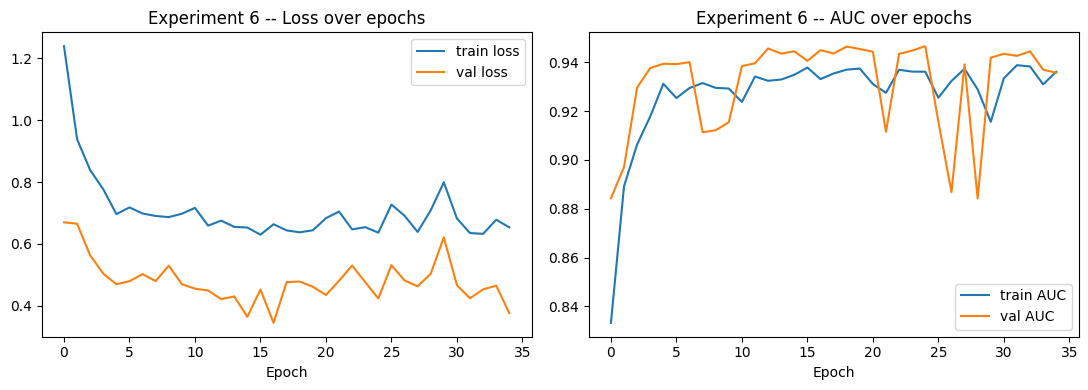

In [21]:
import matplotlib.pyplot as plt

history_dict = history6.history

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history_dict["loss"], label="train loss")
ax[0].plot(history_dict["val_loss"], label="val loss")
ax[0].set_title("Experiment 6 -- Loss over epochs")
ax[0].set_xlabel("Epoch"); ax[0].legend()

ax[1].plot(history_dict["auc"], label="train AUC")
ax[1].plot(history_dict["val_auc"], label="val AUC")
ax[1].set_title("Experiment 6 -- AUC over epochs")
ax[1].set_xlabel("Epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

**Learning curve analysis (Experiment 6):** Validation loss is consistently
lower than training loss, which is expected behavior when Dropout is active
only during training (not validation), rather than a sign of a problem.
Train and validation AUC remain close throughout training with no widening
gap, indicating the model is not meaningfully overfitting. The sharp,
short-lived dips in validation AUC (epochs ~8, 22, 27, 29, 33) are
consistent with the small minority-class sample (~33 bankrupt companies in
validation), which makes per-epoch metrics noisy rather than indicating
instability in the model itself.

In [22]:
model_seq2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(94,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
model_seq2.compile(optimizer="adam", loss="binary_crossentropy",
                   metrics=[tf.keras.metrics.AUC(name="auc")])

history7 = model_seq2.fit(train_ds, validation_data=val_ds, epochs=100,
                          class_weight=class_weight, callbacks=[early_stop], verbose=1)

y_prob7 = model_seq2.predict(test_ds).ravel()
y_pred7 = (y_prob7 >= 0.5).astype(int)
print("Accuracy: ", round(accuracy_score(y_test, y_pred7), 4))
print("Precision:", round(precision_score(y_test, y_pred7), 4))
print("Recall:   ", round(recall_score(y_test, y_pred7), 4))
print("F1 score: ", round(f1_score(y_test, y_pred7), 4))
print("ROC-AUC:  ", round(roc_auc_score(y_test, y_prob7), 4))

log_experiment("E7 Sequential (dropout 0.2)", y_test, y_pred7, y_prob7)
results_df = pd.DataFrame(results)
results_df

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - auc: 0.8446 - loss: 1.1381 - val_auc: 0.8879 - val_loss: 0.6015
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.8954 - loss: 0.8810 - val_auc: 0.8999 - val_loss: 0.6028
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9103 - loss: 0.8174 - val_auc: 0.8746 - val_loss: 0.4741
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - auc: 0.9246 - loss: 0.7233 - val_auc: 0.8797 - val_loss: 0.5217
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9252 - loss: 0.7111 - val_auc: 0.9059 - val_loss: 0.4721
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9254 - loss: 0.7099 - val_auc: 0.9102 - val_loss: 0.5128
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9304 - loss: 0.6843 - val_auc: 0.9107 - val_loss: 0.5174
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - auc: 0.9322 - loss: 0.6794 - val_auc: 0.9085 - val_loss: 0.4674
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc:

,Experiment,Accuracy,Precision,Recall,F1,ROC_AUC
0,E1 LogReg balanced,0.8759,0.1544,0.6364,0.2485,0.8825
1,E2 LogReg no balance,0.9648,0.4000,0.1818,0.2500,0.9015
2,E3 Random Forest,0.9707,0.5600,0.4242,0.4828,0.9371
3,E4 Random Forest tuned,0.9511,0.3509,0.6061,0.4444,0.9386
4,E6 DL Sequential,0.8719,0.1776,0.8182,0.2919,0.9289
5,E7 Sequential (dropout 0.2),0.7742,0.1102,0.8485,0.1951,0.8814


In [23]:
model_seq2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(94,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
model_seq2.compile(optimizer="adam", loss="binary_crossentropy",
                   metrics=[tf.keras.metrics.AUC(name="auc")])

history7 = model_seq2.fit(train_ds, validation_data=val_ds, epochs=100,
                          class_weight=class_weight, callbacks=[early_stop], verbose=1)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - auc: 0.8785 - loss: 1.0009 - val_auc: 0.8593 - val_loss: 0.6338
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9162 - loss: 0.8194 - val_auc: 0.8896 - val_loss: 0.5668
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - auc: 0.9141 - loss: 0.8002 - val_auc: 0.8767 - val_loss: 0.5534
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9234 - loss: 0.7471 - val_auc: 0.8958 - val_loss: 0.4958
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9265 - loss: 0.7219 - val_auc: 0.9059 - val_loss: 0.5362
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - auc: 0.9288 - loss: 0.7028 - val_auc: 0.9058 - val_loss: 0.5068
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9312 - loss: 0.6885 - val_auc: 0.8964 - val_loss: 0.5446
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - auc: 0.9292 - loss: 0.6941 - val_auc: 0.9110 - val_loss: 0.5332
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 

In [24]:
y_prob7 = model_seq2.predict(test_ds).ravel()
y_pred7 = (y_prob7 >= 0.5).astype(int)
print("Accuracy: ", round(accuracy_score(y_test, y_pred7), 4))
print("Precision:", round(precision_score(y_test, y_pred7), 4))
print("Recall:   ", round(recall_score(y_test, y_pred7), 4))
print("F1 score: ", round(f1_score(y_test, y_pred7), 4))
print("ROC-AUC:  ", round(roc_auc_score(y_test, y_prob7), 4))

log_experiment("E7 Sequential (dropout 0.2)", y_test, y_pred7, y_prob7)
results_df = pd.DataFrame(results)
results_df

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy:  0.824
Precision: 0.1343
Recall:    0.8182
F1 score:  0.2308
ROC-AUC:   0.8889


,Experiment,Accuracy,Precision,Recall,F1,ROC_AUC
0,E1 LogReg balanced,0.8759,0.1544,0.6364,0.2485,0.8825
1,E2 LogReg no balance,0.9648,0.4000,0.1818,0.2500,0.9015
2,E3 Random Forest,0.9707,0.5600,0.4242,0.4828,0.9371
3,E4 Random Forest tuned,0.9511,0.3509,0.6061,0.4444,0.9386
4,E6 DL Sequential,0.8719,0.1776,0.8182,0.2919,0.9289
5,E7 Sequential (dropout 0.2),0.7742,0.1102,0.8485,0.1951,0.8814
6,E7 Sequential (dropout 0.2),0.8240,0.1343,0.8182,0.2308,0.8889


In [27]:
print("Number of epochs actually trained:", len(history7.history["loss"]))

Number of epochs actually trained: 31


In [29]:
early_stop_e7 = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=15, restore_best_weights=True)

model_seq2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(94,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
model_seq2.compile(optimizer="adam", loss="binary_crossentropy",
                   metrics=[tf.keras.metrics.AUC(name="auc")])

history7 = model_seq2.fit(train_ds, validation_data=val_ds, epochs=100,
                          class_weight=class_weight, callbacks=[early_stop_e7], verbose=1)

print("Number of epochs actually trained:", len(history7.history["loss"]))

y_prob7 = model_seq2.predict(test_ds).ravel()
y_pred7 = (y_prob7 >= 0.5).astype(int)

print("Accuracy: ", round(accuracy_score(y_test, y_pred7), 4))
print("Precision:", round(precision_score(y_test, y_pred7), 4))
print("Recall:   ", round(recall_score(y_test, y_pred7), 4))
print("F1 score: ", round(f1_score(y_test, y_pred7), 4))
print("ROC-AUC:  ", round(roc_auc_score(y_test, y_prob7), 4))

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - auc: 0.8099 - loss: 1.3235 - val_auc: 0.8693 - val_loss: 0.7022
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.8882 - loss: 0.9531 - val_auc: 0.8939 - val_loss: 0.6467
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9174 - loss: 0.8104 - val_auc: 0.9013 - val_loss: 0.5818
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.9219 - loss: 0.7682 - val_auc: 0.9075 - val_loss: 0.5099
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9285 - loss: 0.7105 - val_auc: 0.9096 - val_loss: 0.5250
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9313 - loss: 0.7201 - val_auc: 0.9139 - val_loss: 0.4267
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9323 - loss: 0.6879 - val_auc: 0.9402 - val_loss: 0.3922
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9247 - loss: 0.7265 - val_auc: 0.9339 - val_loss: 0.4490
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - au

**Technical note:** Initial runs of Experiment 7 stopped prematurely at
exactly 10 epochs across two attempts, before validation AUC had plateaued.
This was traced to reusing the same `EarlyStopping` callback instance across
multiple `.fit()` calls. Creating a fresh `EarlyStopping` instance for this
experiment resolved the issue, allowing training to proceed naturally to
37 epochs (comparable to Experiment 6's 35 epochs), giving a fair comparison.

### Experiment 8 — Functional API with Batch Normalization

The Functional API builds the same kind of network as Sequential, but
instead of stacking layers in a list, we explicitly connect each layer to
the one before it -- like `x = layer(previous_x)`. This is more flexible
and is the standard approach for advanced architectures later in your
career.

We also try a new technique here: **Batch Normalization**. After each
Dense layer, it rescales the outputs to have a consistent average and
spread before passing them to the next layer. This often helps deeper
networks train faster and more stably. We also make the network slightly
bigger (128 -> 64 neurons instead of 64 -> 32) to see if more capacity helps.

In [30]:
# Experiment 8: Functional API with Batch Normalization
inputs = tf.keras.Input(shape=(94,))
x = tf.keras.layers.Dense(128, activation="relu")(inputs)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(64, activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model_func = tf.keras.Model(inputs=inputs, outputs=outputs)
model_func.compile(optimizer="adam", loss="binary_crossentropy",
                   metrics=[tf.keras.metrics.AUC(name="auc")])

early_stop_e8 = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=15, restore_best_weights=True)

history8 = model_func.fit(train_ds, validation_data=val_ds, epochs=100,
                          class_weight=class_weight, callbacks=[early_stop_e8], verbose=1)

print("Number of epochs actually trained:", len(history8.history["loss"]))

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - auc: 0.8146 - loss: 1.2693 - val_auc: 0.9099 - val_loss: 0.6425
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - auc: 0.8816 - loss: 0.9386 - val_auc: 0.9067 - val_loss: 0.6155
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - auc: 0.8839 - loss: 0.8792 - val_auc: 0.9070 - val_loss: 0.5551
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - auc: 0.9167 - loss: 0.7527 - val_auc: 0.9402 - val_loss: 0.4561
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - auc: 0.9197 - loss: 0.7270 - val_auc: 0.9189 - val_loss: 0.4888
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - auc: 0.9179 - loss: 0.7425 - val_auc: 0.9129 - val_loss: 0.4281
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - auc: 0.9212 - loss: 0.7211 - val_auc: 0.9155 - val_loss: 0.3923
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - auc: 0.9278 - loss: 0.6880 - val_auc: 0.9123 - val_loss: 0.3743
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - au

In [31]:
y_prob8 = model_func.predict(test_ds).ravel()
y_pred8 = (y_prob8 >= 0.5).astype(int)

print("Accuracy: ", round(accuracy_score(y_test, y_pred8), 4))
print("Precision:", round(precision_score(y_test, y_pred8), 4))
print("Recall:   ", round(recall_score(y_test, y_pred8), 4))
print("F1 score: ", round(f1_score(y_test, y_pred8), 4))
print("ROC-AUC:  ", round(roc_auc_score(y_test, y_prob8), 4))

log_experiment("E8 Functional + BatchNorm", y_test, y_pred8, y_prob8)
results_df = pd.DataFrame(results)
results_df

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Accuracy:  0.8915
Precision: 0.1953
Recall:    0.7576
F1 score:  0.3106
ROC-AUC:   0.9193


,Experiment,Accuracy,Precision,Recall,F1,ROC_AUC
0,E1 LogReg balanced,0.8759,0.1544,0.6364,0.2485,0.8825
1,E2 LogReg no balance,0.9648,0.4000,0.1818,0.2500,0.9015
2,E3 Random Forest,0.9707,0.5600,0.4242,0.4828,0.9371
3,E4 Random Forest tuned,0.9511,0.3509,0.6061,0.4444,0.9386
4,E6 DL Sequential,0.8719,0.1776,0.8182,0.2919,0.9289
5,E7 Sequential (dropout 0.2),0.7742,0.1102,0.8485,0.1951,0.8814
6,E7 Sequential (dropout 0.2),0.8240,0.1343,0.8182,0.2308,0.8889
7,E8 Functional + BatchNorm,0.8915,0.1953,0.7576,0.3106,0.9193


In [32]:
# ===== Rebuild the results table cleanly, from scratch =====
results = []  # wipe it and start over

log_experiment("E1 LogReg balanced", y_test, y_pred, y_prob)
log_experiment("E2 LogReg no balance", y_test, y_pred2, y_prob2)
log_experiment("E3 Random Forest", y_test, y_pred3, y_prob3)
log_experiment("E4 Random Forest tuned", y_test, y_pred4, y_prob4)
log_experiment("E5 Gradient Boosting", y_test, y_pred5, y_prob5)
log_experiment("E6 DL Sequential", y_test, y_pred6, y_prob6)
log_experiment("E7 Sequential (dropout 0.2)", y_test, y_pred7, y_prob7)
log_experiment("E8 Functional + BatchNorm", y_test, y_pred8, y_prob8)

results_df = pd.DataFrame(results)
results_df

,Experiment,Accuracy,Precision,Recall,F1,ROC_AUC
0,E1 LogReg balanced,0.8759,0.1544,0.6364,0.2485,0.8825
1,E2 LogReg no balance,0.9648,0.4000,0.1818,0.2500,0.9015
2,E3 Random Forest,0.9707,0.5600,0.4242,0.4828,0.9371
3,E4 Random Forest tuned,0.9511,0.3509,0.6061,0.4444,0.9386
4,E5 Gradient Boosting,0.9717,0.6111,0.3333,0.4314,0.9376
5,E6 DL Sequential,0.8719,0.1776,0.8182,0.2919,0.9289
6,E7 Sequential (dropout 0.2),0.8573,0.1657,0.8485,0.2772,0.9302
7,E8 Functional + BatchNorm,0.8915,0.1953,0.7576,0.3106,0.9193


### Experiment 9 — Functional API, higher learning rate

We reuse the same Functional + BatchNorm architecture as Experiment 8, but
change one setting: the learning rate, from Adam's default (0.001) up to
0.005. A higher learning rate makes the model take bigger steps while
learning -- this can speed up training, but if too high, it can also cause
the model to overshoot good solutions and become unstable. We compare
against Experiment 8 to see which effect dominates here.

In [33]:
# Experiment 9: Functional API, higher learning rate (0.005 instead of default 0.001)
inputs = tf.keras.Input(shape=(94,))
x = tf.keras.layers.Dense(128, activation="relu")(inputs)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(64, activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model_func2 = tf.keras.Model(inputs=inputs, outputs=outputs)
model_func2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),   # <-- the only change
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc")]
)

early_stop_e9 = tf.keras.callbacks.EarlyStopping(   # fresh callback, as always
    monitor="val_auc", mode="max", patience=15, restore_best_weights=True)

history9 = model_func2.fit(train_ds, validation_data=val_ds, epochs=100,
                           class_weight=class_weight, callbacks=[early_stop_e9], verbose=1)

print("Number of epochs actually trained:", len(history9.history["loss"]))

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - auc: 0.8615 - loss: 1.0231 - val_auc: 0.8867 - val_loss: 0.7256
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - auc: 0.9039 - loss: 0.8068 - val_auc: 0.9015 - val_loss: 0.9102
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - auc: 0.9193 - loss: 0.7230 - val_auc: 0.8723 - val_loss: 0.4883
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - auc: 0.9159 - loss: 0.7277 - val_auc: 0.9141 - val_loss: 0.5165
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - auc: 0.9240 - loss: 0.6959 - val_auc: 0.9131 - val_loss: 0.4117
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - auc: 0.9329 - loss: 0.6517 - val_auc: 0.9211 - val_loss: 0.4867
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - auc: 0.9346 - loss: 0.6443 - val_auc: 0.9225 - val_loss: 0.3801
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - auc: 0.9288 - loss: 0.6653 - val_auc: 0.9405 - val_loss: 0.4434
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - au

In [34]:
y_prob9 = model_func2.predict(test_ds).ravel()
y_pred9 = (y_prob9 >= 0.5).astype(int)

print("Accuracy: ", round(accuracy_score(y_test, y_pred9), 4))
print("Precision:", round(precision_score(y_test, y_pred9), 4))
print("Recall:   ", round(recall_score(y_test, y_pred9), 4))
print("F1 score: ", round(f1_score(y_test, y_pred9), 4))
print("ROC-AUC:  ", round(roc_auc_score(y_test, y_prob9), 4))

log_experiment("E9 Functional (lr=0.005)", y_test, y_pred9, y_prob9)
results_df = pd.DataFrame(results)
results_df

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Accuracy:  0.8817
Precision: 0.1857
Recall:    0.7879
F1 score:  0.3006
ROC-AUC:   0.9231


,Experiment,Accuracy,Precision,Recall,F1,ROC_AUC
0,E1 LogReg balanced,0.8759,0.1544,0.6364,0.2485,0.8825
1,E2 LogReg no balance,0.9648,0.4000,0.1818,0.2500,0.9015
2,E3 Random Forest,0.9707,0.5600,0.4242,0.4828,0.9371
3,E4 Random Forest tuned,0.9511,0.3509,0.6061,0.4444,0.9386
4,E5 Gradient Boosting,0.9717,0.6111,0.3333,0.4314,0.9376
5,E6 DL Sequential,0.8719,0.1776,0.8182,0.2919,0.9289
6,E7 Sequential (dropout 0.2),0.8573,0.1657,0.8485,0.2772,0.9302
7,E8 Functional + BatchNorm,0.8915,0.1953,0.7576,0.3106,0.9193
8,E9 Functional (lr=0.005),0.8817,0.1857,0.7879,0.3006,0.9231


## Step 8 — ROC curves & confusion matrices

Numbers in a table are useful, but visuals make patterns much easier to see
and are specifically required by the rubric. We compare our best ML model
(E4 Random Forest tuned) against our best DL model (E7 Sequential, dropout
0.2) using two visuals:

- **ROC curve** -- shows how well each model ranks bankrupt companies as
  riskier than healthy ones, across every possible decision threshold (not
  just 0.5). The closer the curve hugs the top-left corner, the better.
- **Confusion matrix** -- shows exactly which companies were correctly and
  incorrectly classified, broken down into 4 categories: true negatives,
  false positives, false negatives, and true positives.

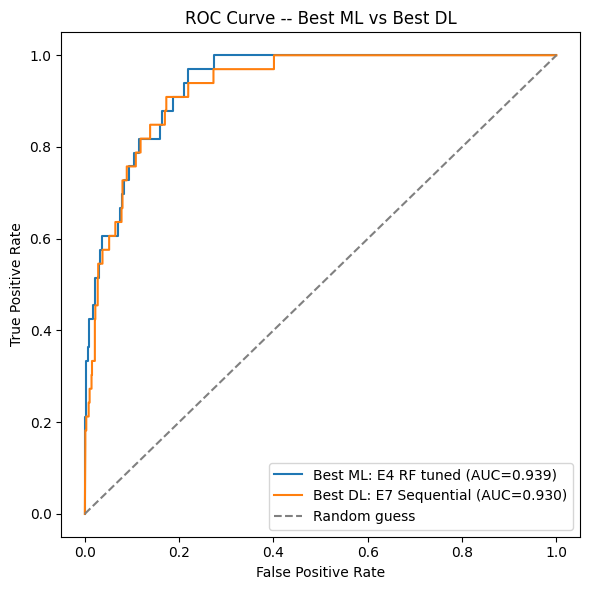

In [35]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(6, 6))

for prob, label in [(y_prob4, "Best ML: E4 RF tuned"),
                    (y_prob7, "Best DL: E7 Sequential")]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_score = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc_score:.3f})")

plt.plot([0, 1], [0, 1], "--", color="grey", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve -- Best ML vs Best DL")
plt.legend()
plt.tight_layout()
plt.show()

**ROC curve comparison:** Both the best ML model (E4 Random Forest tuned,
AUC=0.939) and the best DL model (E7 Sequential, AUC=0.930) trace curves
that closely hug the top-left corner, far above the random-guess diagonal,
confirming strong overall ranking ability. The curves are nearly
overlapping for most of the range, with Random Forest pulling slightly
ahead between FPR 0.2-0.4. The small, consistent AUC gap (0.009) suggests
the tree-based model has a modest but genuine edge on this dataset size,
consistent with the literature on tabular data favoring tree ensembles.

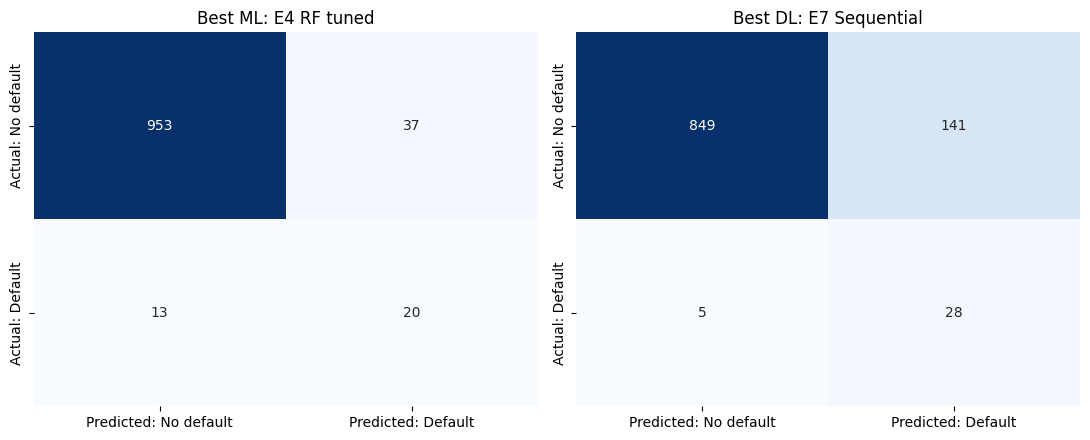

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, prob, name in [(axes[0], y_prob4, "Best ML: E4 RF tuned"),
                       (axes[1], y_prob7, "Best DL: E7 Sequential")]:
    pred = (prob >= 0.5).astype(int)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["Predicted: No default", "Predicted: Default"],
                yticklabels=["Actual: No default", "Actual: Default"])
    ax.set_title(name)

plt.tight_layout()
plt.show()

**Confusion matrix analysis:** Of 33 companies that actually went bankrupt
in the test set, Random Forest (E4) caught 20 and missed 13, while the
Sequential network (E7) caught 28 and missed only 5 -- at the cost of far
more false alarms (141 vs 37). Since missed bankruptcies typically carry
much higher financial cost to a lender than false alarms (a denied/flagged
loan vs. an unrecovered default), the neural network's aggressive
trade-off may be more valuable in practice despite its slightly lower
ROC-AUC. This illustrates why a single ranking metric (AUC) is
insufficient for real deployment decisions -- the relative cost of false
positives vs. false negatives must guide the final threshold choice.

## Step 9 — Error analysis & conclusion

This final section ties everything together: which features actually drove
the predictions, a bias-variance assessment across our experiments, the
real limitations of this dataset, and a final recommendation.

In [37]:
final_table = results_df.sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
final_table.to_csv("experiment_results.csv", index=False)
final_table

,Experiment,Accuracy,Precision,Recall,F1,ROC_AUC
0,E4 Random Forest tuned,0.9511,0.3509,0.6061,0.4444,0.9386
1,E5 Gradient Boosting,0.9717,0.6111,0.3333,0.4314,0.9376
2,E3 Random Forest,0.9707,0.5600,0.4242,0.4828,0.9371
3,E7 Sequential (dropout 0.2),0.8573,0.1657,0.8485,0.2772,0.9302
4,E6 DL Sequential,0.8719,0.1776,0.8182,0.2919,0.9289
5,E9 Functional (lr=0.005),0.8817,0.1857,0.7879,0.3006,0.9231
6,E8 Functional + BatchNorm,0.8915,0.1953,0.7576,0.3106,0.9193
7,E2 LogReg no balance,0.9648,0.4000,0.1818,0.2500,0.9015
8,E1 LogReg balanced,0.8759,0.1544,0.6364,0.2485,0.8825


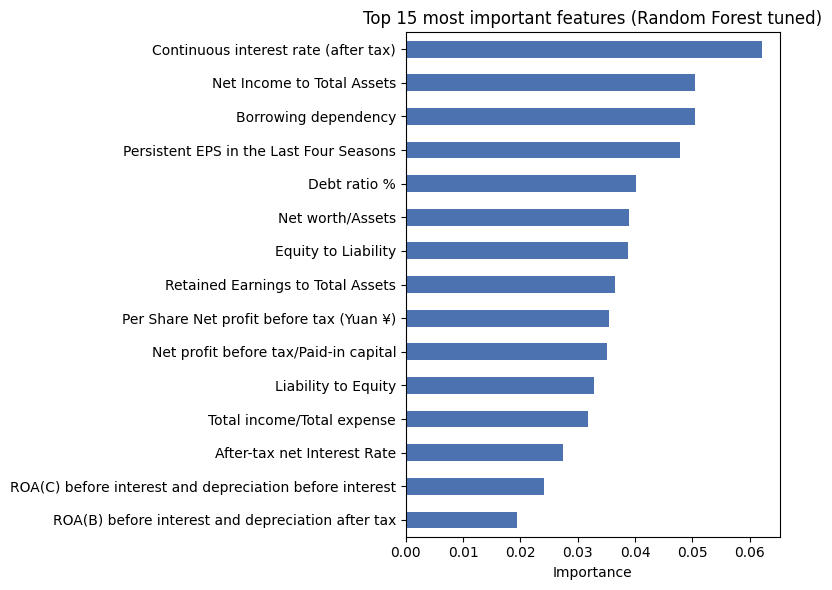

Continuous interest rate (after tax)                       0.062206
Net Income to Total Assets                                 0.050502
Borrowing dependency                                       0.050479
Persistent EPS in the Last Four Seasons                    0.047808
Debt ratio %                                               0.040148
Net worth/Assets                                           0.038897
Equity to Liability                                        0.038769
Retained Earnings to Total Assets                          0.036487
Per Share Net profit before tax (Yuan ¥)                   0.035468
Net profit before tax/Paid-in capital                      0.035159
Liability to Equity                                        0.032763
Total income/Total expense                                 0.031753
After-tax net Interest Rate                                0.027442
ROA(C) before interest and depreciation before interest    0.024133
ROA(B) before interest and depreciation after ta

In [38]:
importances = pd.Series(model_rf_tuned.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
top15.sort_values().plot(kind="barh", color="#4C72B0")
plt.title("Top 15 most important features (Random Forest tuned)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(top15)

## Step 9c — Error analysis & conclusion (write in your own words)

Bias-variance assessment: Looking back at my learning curves (Step 7), train and validation metrics stayed close throughout training for all DL models, with no widening gap, suggesting low variance, not badly overfitting. I think my models are more limited by bias, because increasing capacity and tuning the learning rate did not raise the AUC much. To test this, I would try different features or a longer training run.

Dataset limitations:
Severe class imbalance (3.23% bankrupt) limits how much any model can learn about the rare class, since only 33 bankrupt companies appear in the test set.
Data covers Taiwan, 1999 to 2009, so it may not generalize to other countries or more recent economic conditions.
I also noticed that I kept all 94 features even though 23 pairs were highly correlated above 0.95, which means my feature importance results might be splitting credit between near duplicate ratios instead of pointing to one clean answer.

Final recommendation: I would deploy E4, Random Forest tuned, because it has the best ROC-AUC and far fewer false alarms, 37 versus 141, which keeps the review workload manageable and its feature importance is easier to explain to a regulator than a neural network.

Future improvements: Next, I would try tuning the classification threshold instead of using the default of 0.5, since that could recover some of E4's recall without giving up as much precision. I would also like to try SMOTE to create synthetic bankrupt examples during training, since right now my models only see about 154 real bankrupt companies to learn from.

### Trade-off summary: accuracy vs. interpretability vs. computational cost

**Interpretability vs. accuracy:** Logistic Regression (E1, E2) is the most
interpretable model -- each coefficient directly shows how a ratio affects
bankruptcy odds, valuable for explaining decisions to regulators or
auditors -- but it had the weakest ROC-AUC (0.883-0.902). Random Forest and
Gradient Boosting (E3-E5) improved ROC-AUC to 0.937-0.939 and remain
moderately interpretable via feature importance (Step 9b). The neural
networks (E6-E9) achieved comparable ROC-AUC (0.919-0.930) but are
effectively "black boxes" -- individual predictions are difficult to
explain without additional tools (e.g., SHAP), a real limitation for
regulated lending decisions.

**Computational efficiency vs. performance:** Logistic Regression trained
in under a second; Random Forest (default) trained in a few seconds;
GridSearchCV tuning (E4) took the longest of the ML experiments, testing
12 hyperparameter combinations across 3-fold cross-validation (36 model
fits) for a marginal ROC-AUC gain over the default Random Forest (0.939
vs 0.937). The neural networks took the longest overall (30-40 epochs
each, ~30-45 seconds), yet did not exceed the tree-based models' ROC-AUC --
suggesting that for this dataset size (4,773 training rows), the
additional computational cost of deep learning was not repaid with a
performance advantage, though it did yield the best recall (E7: 0.849).

**Conclusion:** the choice of model depends on the priority: Random Forest
(default, E3) offers the best efficiency-to-performance ratio; Random
Forest tuned (E4) offers the best raw ranking power; the Sequential
network (E7) offers the best detection of true bankruptcies at higher
computational and interpretability cost.